Made by Pranay Venkatesh, April 2025

# Tavis Cummings

In [1]:
import numpy as np
import matplotlib.pyplot as plt

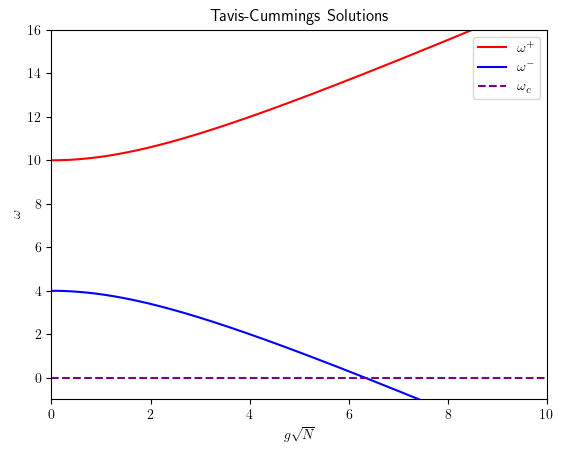

In [2]:
gns = np.linspace(0.0, 10.0, 10000)
w = 4.0
w0 = 10.0
g = 0.1
wplus = (w + w0)/2 + np.sqrt(((w - w0)/2)**2 + (gns)**2)
wminus = (w + w0)/2 - np.sqrt(((w - w0)/2)**2 + (gns)**2)
plt.rcParams['text.usetex'] = True
plt.xlim(0.0, 10.0)
plt.ylim(-1.0, 16.0)
plt.ylabel(r"$\omega$")
plt.xlabel(r"$g \sqrt{N}$")
plt.plot(gns, wplus, 'r-', label=r"$\omega^{+}$")
plt.plot(gns, wminus, 'b-', label=r"$\omega^{-}$")
plt.axhline(y=0.0, color='purple', linestyle='--', label=r"$\omega_c$")
plt.title("Tavis-Cummings Solutions")
plt.legend()
plt.savefig("TC-fig1b.png")

# Phase Diagram of Generalized Dicke Model

In [3]:
omega = 1.0
omega0 = 1.0
k = 1.0
g = 0.9
GammaT = 0.5
def stab(G, gr):
    Gammau = G*0.5
    gp = gr*g
    Gammad = GammaT - Gammau
    sigmaz_ns = (Gammau - Gammad)/(GammaT)
    M = np.array([
            [-k/2 - 1.0j*omega, 0.0, -1.0j*g, -1.0j*gp],
            [0.0, -k/2 + 1.0j*omega, 1.0j*gp, 1.0j*g],
            [1.0j*g*sigmaz_ns, 1.0j*gp*sigmaz_ns, -GammaT/2 - 1.0j*omega0, 0.0],
            [-1.0j*gp*sigmaz_ns, -1.0j*g*sigmaz_ns, 0.0, -GammaT/2 + 1.0j*omega0]
        ])
    eigenvalues = np.linalg.eigvals(M)
    count = 0
    for eig in eigenvalues:
        if np.real(eig)>0:
            count+=1
    #print(eigenvalues)
    return count

In [4]:
import matplotlib.colors as mcolors

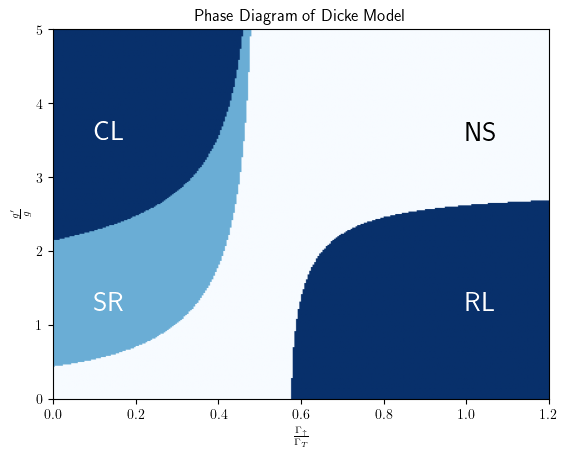

In [5]:
X = np.linspace(0, 1.2, 300)  
Y = np.linspace(0, 5.0, 300)  

Z = np.zeros((len(X), len(Y)))
for j in range(len(Y)):
    for i in range(len(X)):
        Z[j][i] = stab(X[i], Y[j])

plt.rcParams['text.usetex'] = True

plt.xlabel(r'$\frac{\Gamma_{\uparrow}}{\Gamma_T}$')
plt.ylabel(r"$\frac{g'}{g}$")
plt.title('Phase Diagram of Dicke Model')
plt.imshow(Z, extent=[X.min(), X.max(), Y.min(), Y.max()],
           origin='lower', cmap='Blues', aspect='auto')
plt.text(0.1, 1.2, "SR", color="white", fontsize=20)
plt.text(0.1, 3.5, "CL", color="white", fontsize=20)
plt.text(1.0, 1.2, "RL", color="white", fontsize=20)
plt.text(1.0, 3.5, "NS", color="black", fontsize=20)
plt.savefig("phase-diagram.png")
plt.show()

# Exact Diagonalization

In [6]:
def ed(l):
    nsteps = 20000
    dt = 0.1
    
    gamma = 0.05
    omega_c = 1.0
    omega_s = 1.0
    
    beta = 40.0

    delta = l*np.sqrt(np.tanh(beta*omega_s/2.0))
    ntot = 2
    
    hmat = np.zeros((2*ntot,2*ntot),dtype=np.complex128)
    
    hmat[0,0] = 1.0j*omega_c 
    hmat[1,1] = -1.0j*omega_c
     
    hmat[2,2] = 1.0j*omega_s
    hmat[3,3] = -hmat[2,2]
    
    hmat[0,2] = 1.0j*delta
    hmat[0,3] = hmat[0,2]
    
    hmat[1,2] = -1.0j*delta
    hmat[1,3] = hmat[1,2]
    
    hmat[2,0] = 1.0j*delta
    hmat[2,1] = hmat[2,0]
    
    hmat[3,0] = -1.0j*delta
    hmat[3,1] = hmat[3,0]
    
    hv, hphi = np.linalg.eig(hmat)
    
    hphi_i = np.linalg.inv(hphi)
    
    n_a  = 1.0
    n_a1 = 2.0
    res = 0.0
    z = 0.0
    for i in range(20):
      res += i*np.exp(-beta*omega_s*i)
      z += np.exp(-beta*omega_s*i)
    
    n_b = 1.0/(np.exp(beta*omega_s) - 1.0)

    n_b1 = 1 + n_b

    ts = []
    nphotons = []
    for i in range(nsteps):
      t1 = i*dt
      hmat_d = np.zeros((2*ntot,2*ntot),dtype=np.complex128)
      for i in range(2*ntot): 
        hmat_d[i,i] = np.exp(hv[i]*t1)
      hmat_new = np.matmul(hphi ,np.matmul(hmat_d, hphi_i))
    
      n_photon =   hmat_new[0,0]*hmat_new[1,1]*n_a +  hmat_new[0,1]*hmat_new[1,0]*n_a1 \
                   + hmat_new[0,2]*hmat_new[1,3]*n_b + hmat_new[0,3]*hmat_new[1,2]*n_b1
      ts.append(t1)
      nphotons.append(n_photon.real)
    return ts, nphotons

/tmp/ipykernel_193623/3138217618.py:59: RuntimeWarning: overflow encountered in scalar add
  n_photon =   hmat_new[0,0]*hmat_new[1,1]*n_a +  hmat_new[0,1]*hmat_new[1,0]*n_a1 \
/tmp/ipykernel_193623/3138217618.py:59: RuntimeWarning: overflow encountered in scalar multiply
  n_photon =   hmat_new[0,0]*hmat_new[1,1]*n_a +  hmat_new[0,1]*hmat_new[1,0]*n_a1 \
/tmp/ipykernel_193623/3138217618.py:59: RuntimeWarning: invalid value encountered in scalar multiply
  n_photon =   hmat_new[0,0]*hmat_new[1,1]*n_a +  hmat_new[0,1]*hmat_new[1,0]*n_a1 \
/tmp/ipykernel_193623/3138217618.py:60: RuntimeWarning: overflow encountered in scalar multiply
  + hmat_new[0,2]*hmat_new[1,3]*n_b + hmat_new[0,3]*hmat_new[1,2]*n_b1
/tmp/ipykernel_193623/3138217618.py:60: RuntimeWarning: invalid value encountered in scalar multiply
  + hmat_new[0,2]*hmat_new[1,3]*n_b + hmat_new[0,3]*hmat_new[1,2]*n_b1
/tmp/ipykernel_193623/3138217618.py:56: RuntimeWarning: overflow encountered in exp
  hmat_d[i,i] = np.exp(hv[i]*t1)
/

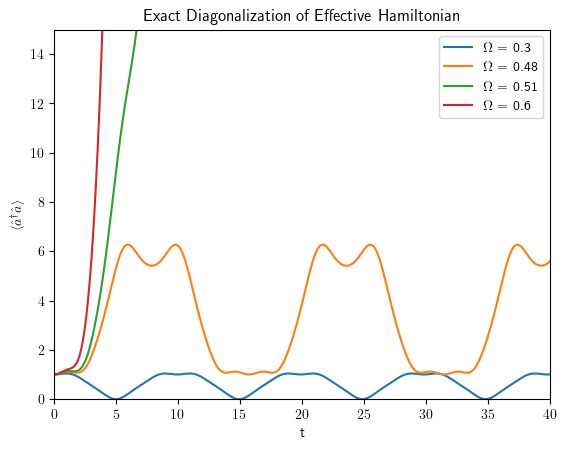

In [7]:
l = [0.3, 0.48, 0.51, 0.6]
t1, nph1 = ed(l[0])
t2, nph2 = ed(l[1])
t3, nph3 = ed(l[2])
t4, nph4 = ed(l[3])

plt.rcParams['text.usetex'] = True
plt.title("Exact Diagonalization of Effective Hamiltonian")
plt.xlim(0.0, 40.0)
plt.ylim(0.0, 15.0)
plt.xlabel("t")
plt.ylabel(r"$\langle \hat{a}^{\dagger} \hat{a}\rangle$")
plt.plot(t1, nph1, label=rf"$\Omega$ = {l[0]}")
plt.plot(t2, nph2, label=rf"$\Omega$ = {l[1]}")
plt.plot(t3, nph3, label=rf"$\Omega$ = {l[2]}")
plt.plot(t4, nph4, label=rf"$\Omega$ = {l[3]}")

plt.legend()
plt.show()